<style>
    pre {
        white-space: pre-wrap;
        word-wrap: break-word;
    }
</style>

<div style="display:flex; justify-content:space-around; align-items:center; background-color:#cccccc; padding:5px; border:2px solid #333333;">
    <a href="https://www.um.es/web/estudios/grados/ciencia-ingenieria-datos/" target="_blank">
    <img src="https://www.um.es/documents/1073494/42130150/LogosimboloUMU-positivo.png" alt="UMU" style="height:200px; width:auto;">
    <a href="https://estudios.upct.es/grado/5251/inicio" target="_blank">
    <img src="https://www.upct.es/contenido/universidad/galeria/identidad-2021/logos/logos-upct/marca-upct/marca-principal/horizontal/azul.png" alt="UPCT" style="height:145px; width:auto;">
</div>

# Asignatura: **Deep Learning**

## Titulación: **Grado en Ciencia e Ingeniería de Datos**

## Práctica 3: Transformers
### **Sesión 1/3: Preprocesamiento de secuencias de caracteres**

**Autores**: Antonio Martínez Sánchez, Juan Morales Sánchez, José Luís Sancho Gómez y Juan Antonio Botía Blaya

<div style="page-break-before: always;"></div>

### Contenidos
- [Requisitos](#requisitos)
- [El dataset](#dataset)
- [Codificación](#code)
- [El problema: clasificación de péptidos](#problema)
- [Ejercicios](#ejercicios)

### Requisitos
<a class='anchor' id='requisitos'></a>

Se trabajará con notebooks de [Jupyter](https://jupyter.org/install) con código Python empleando como intérprete la última versión de [Miniconda](https://docs.anaconda.com/miniconda/). Se requiere la preinstalación (se recomienda utilizar [pip](https://pypi.org/project/pip/)) de los siguientes paquetes de Python:

- [Numpy](https://pypi.org/project/numpy/) (computación numérica)
- [Tensorflow](https://www.tensorflow.org/install/pip?hl=es-419#linux) que incluye a Keras (deep learning)
- [Scikit-learn](https://pypi.org/project/scikit-learn/) (machine learning)
- [Matplotlib](https://pypi.org/project/matplotlib/) (visualización de datos)
- [Pandas](https://pypi.org/project/seaborn/) (manipulación de datos tabulados)

### El dataset
<a class='anchor' id='dataset'></a>

Los péptidos son moléculas biológicas formadas por secuencias cortas de aminoácidos, pudiendo llegar hasta aproximadamente los 100 aminoácidos, a partir de esta cantidad a un péptido se le suele denominar proteína. Los aminoácidos (AA) son los ladrillos de los péptidos, que a su vez son los componentes fundamentales de la estructura y maquinaria celular. Las secuencias de AA que determinan la estructura y función de un péptido están codificadas en los genes, las unidades de información almacenadas en el ADN de los seres vivos. Un gen es un fragmento de ADN que contine una secuencia de nucleótidos que es **transcrito** a un fragmento de ARNm (un intermediario que mantiene la información) y que al alcanzar un ribosoma (la fábrica de péptidos) es **trasladado** a una secuencia de AA. Esta secuencia determina como el péptidos deben plegarse sobre si mismos para generar la estructura 3D que le confiere sus propiedades físico-químicas. Por tanto, estudiando la secuencia de AA de un péptido se puede determinar su función y analizar su función biológica.

![ADN_to_AA](figs/ADN_AA_traduccion.jpg)

Los datos a procesar en esta práctica son dos tablas almacenadas en formato CSV con la secuencia de AAs de una serie de péptidos. La primera columna contine el identificador de los péptidos, para nostros no tiene mayor relevancia. La columna 'aa_seq' contiene la secuencia de AAs codificada con caracteres en mayúscula, cada carácter se corresponde con un AA. Finalmente, la columna 'AMP' determina si este péptido tiene algún efecto antimicrobiano. Cada tabla contiene péptidos diferentes, la tabla *non_amp_ampep_cdhit90.csv* contine péptidos sin efecto antimicrobiano y la tabla *veltri_dramp_cdhit_90.csv' contine péptidos con efecto antimicrobiano o clasificados como AMP.

### Codificación
<a class='anchor' id='code'></a>

Las redes neuronales procesan tensores cuyos valores son numéricos. No obstante, en algunos casos los datos de partida son conjuntos o secuencias de caracteres. El ejemplo más claro es el texto, por ejemplo, este párrafo contine una secuencia de caracteres que, si obviamos los signos de puntuación y acentuación, está formado por las letras del abecedario. En el contexto del lenguaje expresado en este párrafo, los carácteres no tienen ningún significado (semántica) de forma aislada. De forma simplista podemos asumir que las unidades semánticas, o **tokens**, del lenguaje natural son las palabras. Puesto que una red neuronal no puede procesar directamente los tokens en forma de palabras, es necesario codificaros previamente empleando valores numéricos. El **vocabulario** de un lenguaje es el conjunto de los diferentes tokens, en caso de los lenguajes naturales puede tener cientos de miles de elementos dificultando su codificación.

El dataset de esta práctica está expresado en un lenguaje más sencillo y menos ambiguo que el lenguaje natural pero también codificable en forma de texto. En este caso, los tokens están claramente definidos y se corresponden con cada carácter de la secuencia de AA de un péptido, de tal modo, que cada carácter identifica unívocamente un AA. Por tanto, el vocabulario del lenguaje de los péptidos se limita a un conjunto reducido de AA representados en un fichero CSV con caracteres individuales (letras mayúsculas). Un péptido se corresponde con una secuencia de AAs (letras) cuya longitud es variable. 

En esta práctica utilizaremos los métodos de codificación más directos:
- Integer: se construye una tabla con todos los tokens considerados y se le asigna un índice entero a cada token. Luego a cada token de la secuencia se le asigna el índice correspondiente. Como las secuencias tienen tamaños diferentes, se suele configurar para que los vectores de salida tengan el tamaño de la secuencia más larga asignándose un 0 a los valores de relleno (*padding*).
- Multi-hot: la codificación de salida es un vector binario cuyo tamaño es el número de tokens considerados, si un token aparece en la secuencia codificada el vector tendrá un 1 en la posición correspondiente a ese token, si no un 0. Independientemente del tamaño de la secuencia a codificar, la salida será un vector cuyo tamaño se corresponde con la longitud del vocabulario.
- TF-IDF: es una extensión de multi-hot que en lugar de valores binarios asigna la frecuencia de aparición de un token en un conjunto de datos.

La librería Keras proporciona la clase [TextVectorization](https://keras.io/api/layers/preprocessing_layers/text/text_vectorization/) que implementa una capa para la codificación de texto.

### El problema: clasificación de péptidos
<a class='anchor' id='problema'></a>

Durante esta práctica abordaremos el problema de la clasificación de fragmentos de texto. En concreto, nos centraremos en la clasificación de péptidos, secuencias de AAs, codificadas mediante caracteres de texto. Los péptidos se pueden agrupar en dos clases según presenten o no actividad antimicrobiana (AMP). Los CSV de entrada están separados entre los AMP y los no AMP, así que deberán fusionarse para construir un dataset que permita un entrenamiento supervisado.

En las diferentes sesiones de esta práctica construiremos diferentes modelos para resolver este problema. El punto de partida será la arquitectura genérica MLP, utilizaremos también redes neuronales recurrentes (RNN) para estudiar la ventaja de procesar datos en forma de secuencia y finalmente implementaremos un Transformer que se ha convertido en el modelo de referencia para este tipo de datos.

### Ejercicios
<a class='anchor' id='ejercicios'></a>

**E1:** Carga las tablas almacenadas en los CSV utilizando la librería Pandas y fusiónalas en un solo Dataframe. Después construye una lista con todos los péptidos y otra cuyos elementos sean booleanos identificando si son AMP. ¿Cuál es la secuencia más larga? ¿Cuántos AAs diferentes hay? ¿Cuál es el vocabulario del lenguaje?

**E2:** Divide los conjuntos de datos del E1 en dos. Uno que contenga el 80% de las secuencias para el entrenamiento supervisado y otro que contenga al resto para testear los modelos entrenados. Asegúrate que en ambos conjuntos hay una selección representativos de péptidos.

**E3:** Codifica los péptidos empleando la codificación multi-hot. ¿Qué longitud tiene cada péptido codificado?

**E4:** Basándote en la arquitectura del E4 de la Sesión 1 de la Práctica 2 (Redes Convolucionales), construye un MLP para clasificar los péptidos. ¿Cuántos parámetros a entrenar tiene?

**E5:** Entrena el modelo del E4 utilizando el 20% de los datos de entrenamiento para validación durante el entrenamiento. Utiliza una cantidad de épocas que produzca sobreajuste, además añade un *callback* para guardar el modelo que tenga una mayor precisión en la validación.

**E6:** Testea la precisión del modelo entrenado en el E5 empleando el conjunto de test obtenido en el E2. Recuerda cargar el modelo para la mejor época. ¿Qué precisión se alcanza?

**E7:** Repite los ejercicios E3-6 pero esta vez empleando codificación TF-IDF. ¿Ha mejorado la precisión? ¿por qué?

**E8:** Hasta ahora hemos trabajado solo con unigramas, los tokens están compuesto por AAs aislados. También es posible construir tokens con combinaciones de AAs (n-gramas). Repite el ejercicio E7 pero esta vez empleando bigramas. ¿Qué tamaño tiene el vocabulario ahora? ¿Por qué MLP ha aumentado considerablemente el número de parámetros a entrenar? ¿Qué ventaja podría aportar el trabajar con n-gramas (n > 1) en comparación de unigramas?

In [1]:
# === Imports ===
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

I0000 00:00:1776183703.222829  143307 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776183703.250775  143307 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1776183703.936978  143307 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# === E1: Carga, fusión y análisis ===
non_amp_path = "data/in/non_amp_ampep_cdhit90.csv"
amp_path = "data/in/veltri_dramp_cdhit_90.csv"

df_non = pd.read_csv(non_amp_path, index_col=0)
df_amp = pd.read_csv(amp_path, index_col=0)

df = pd.concat([df_non, df_amp], axis=0, ignore_index=True)

# Normalizar secuencias para evitar duplicados por mayúsculas/minúsculas
df["aa_seq"] = df["aa_seq"].astype(str).str.strip().str.upper()

# Calcular de nuevo la longitud por seguridad
df["aa_len"] = df["aa_seq"].str.len()

df = df[["aa_seq", "aa_len", "AMP"]].copy()
df["AMP"] = df["AMP"].astype(int)

peptides = df["aa_seq"].tolist()
labels = df["AMP"].tolist()

max_len = max(len(s) for s in peptides)
longest_seq = max(peptides, key=len)
vocab = sorted(set("".join(peptides)))
n_aas = len(vocab)

print("=== E1 ===")
print(f"Número total de péptidos: {len(df)}")
print(f"Longitud máxima de secuencia: {max_len}")
print(f"Secuencia más larga: {longest_seq}")
print(f"Número de AAs distintos: {n_aas}")
print(f"Vocabulario: {vocab}")
print(df["AMP"].value_counts().rename(index={0: "No AMP", 1: "AMP"}))

=== E1 ===
Número total de péptidos: 3973
Longitud máxima de secuencia: 101
Secuencia más larga: MMLEYVLGLSAYLFSIGIYGLITSRNMVRALMCLELILNAVNLNFVTFSDFFDSRQLKGNILSIFVISIAAAEAAIGPAIVSSIYRNRKSIRINQLNLLNK
Número de AAs distintos: 25
Vocabulario: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
AMP
AMP       2065
No AMP    1908
Name: count, dtype: int64


In [3]:
# === E2: Split estratificado 80/20 ===
X = np.array(peptides)
y = np.array(labels)

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y
)

print("=== E2 ===")
print(f"Train: {len(X_train_text)} secuencias")
print(f"Test: {len(X_test_text)} secuencias")
print(f"Distribución train: {np.bincount(y_train)}")
print(f"Distribución test: {np.bincount(y_test)}")

=== E2 ===
Train: 3178 secuencias
Test: 795 secuencias
Distribución train: [1526 1652]
Distribución test: [382 413]


In [4]:
# === E3: Codificación multi-hot (unigramas) ===

vectorizer_mh = layers.TextVectorization(
    standardize=None, split="character", output_mode="multi_hot"
)
vectorizer_mh.adapt(X_train_text)
X_train_mh = vectorizer_mh(tf.constant(X_train_text)).numpy()
X_test_mh = vectorizer_mh(tf.constant(X_test_text)).numpy()
vocab_mh = vectorizer_mh.get_vocabulary()
dim_mh = X_train_mh.shape[1]

print("=== E3 ===")
print(f"Tamaño vocabulario multi-hot: {len(vocab_mh)}")
print(f"Longitud de cada péptido codificado: {dim_mh}")
print(f"Forma train codificada: {X_train_mh.shape}")
print(f"Forma test codificada: {X_test_mh.shape}")

=== E3 ===
Tamaño vocabulario multi-hot: 25
Longitud de cada péptido codificado: 25
Forma train codificada: (3178, 25)
Forma test codificada: (795, 25)


W0000 00:00:1776183705.422011  143307 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [5]:
# === E4: MLP baseline para clasificación AMP/no-AMP ===

mlp_mh = keras.Sequential(
    [
        layers.Input(shape=(dim_mh,)),
        layers.Dense(512, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ],
    name="MLP_multi_hot",
)

mlp_mh.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

print("=== E4 ===")
mlp_mh.summary()

=== E4 ===


Model: "MLP_multi_hot"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │        13,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,857 (726.00 KB)

 Trainable params: 185,857 (726.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60


 1/80 ━━━━━━━━━━━━━━━━━━━━ 40s 517ms/step - accuracy: 0.5625 - loss: 0.6800

39/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5970 - loss: 0.6591   

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6318 - loss: 0.6317


Epoch 1: val_accuracy improved from None to 0.73585, saving model to models/best_mlp_multi_hot.keras


...

Epoch 60/60


 1/80 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8750 - loss: 0.1916

44/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9164 - loss: 0.1614 


Epoch 60: val_accuracy did not improve from 0.73585


80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9150 - loss: 0.1591 - val_accuracy: 0.6903 - val_loss: 1.7680


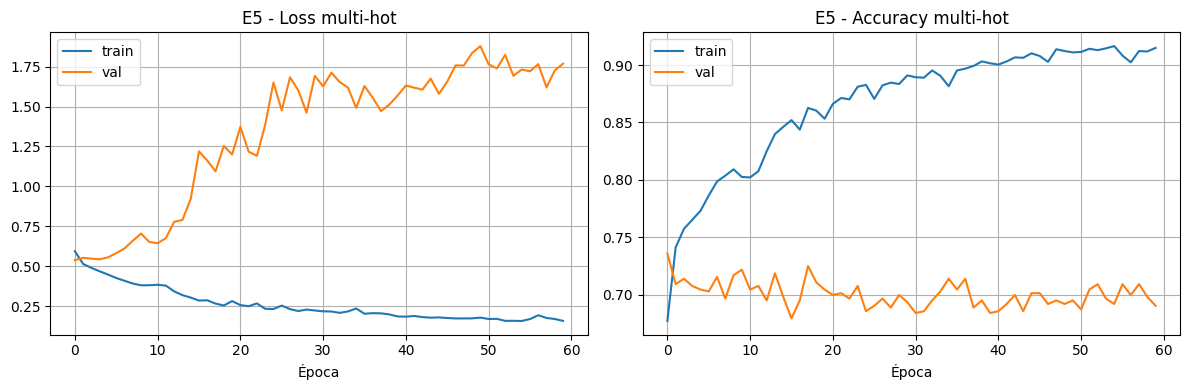

In [6]:
# === E5: Entrenar con validación y checkpoint ===
os.makedirs("models", exist_ok=True)
ckpt_mh_path = "models/best_mlp_multi_hot.keras"
cb_mh = keras.callbacks.ModelCheckpoint(
    filepath=ckpt_mh_path,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1,
)

history_mh = mlp_mh.fit(
    X_train_mh,
    y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=32,
    callbacks=[cb_mh],
    verbose=1,
)

# Gráficas para ver sobreajustes

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history_mh.history["loss"], label="train")
ax[0].plot(history_mh.history["val_loss"], label="val")
ax[0].set_title("E5 - Loss multi-hot")
ax[0].set_xlabel("Época")
ax[0].legend()
ax[0].grid(True)
ax[1].plot(history_mh.history["accuracy"], label="train")
ax[1].plot(history_mh.history["val_accuracy"], label="val")
ax[1].set_title("E5 - Accuracy multi-hot")
ax[1].set_xlabel("Época")
ax[1].legend()
ax[1].grid(True)
plt.tight_layout()
plt.show()

In [7]:
# === E6: Test del mejor modelo multi-hot ===
best_mh = keras.models.load_model(ckpt_mh_path)
loss_mh, acc_mh = best_mh.evaluate(X_test_mh, y_test, verbose=0)

print("=== E6 ===")
print(f"Test loss multi-host: {loss_mh:.4f}")
print(f"Test accuracy multi-host: {acc_mh:.4f} ({acc_mh * 100:.2f}%)")

=== E6 ===
Test loss multi-host: 0.5380
Test accuracy multi-host: 0.7296 (72.96%)


In [8]:
# === E7: TF-IDF unigramas + MLP ===
vectorizer_tfidf = layers.TextVectorization(
    standardize=None, split="character", output_mode="tf_idf"
)
vectorizer_tfidf.adapt(X_train_text)
X_train_tfidf = vectorizer_tfidf(tf.constant(X_train_text)).numpy()
X_test_tfidf = vectorizer_tfidf(tf.constant(X_test_text)).numpy()
dim_tfidf = X_train_tfidf.shape[1]
mlp_tfidf = keras.Sequential(
    [
        layers.Input(shape=(dim_tfidf,)),
        layers.Dense(512, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ],
    name="MLP_tfidf_unigram",
)

mlp_tfidf.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

ckpt_tfidf_path = "models/best_mlp_tfidf_unigram.keras"
cb_tfidf = keras.callbacks.ModelCheckpoint(
    filepath=ckpt_tfidf_path,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1,
)

history_idf = mlp_tfidf.fit(
    X_train_tfidf,
    y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=32,
    callbacks=[cb_tfidf],
    verbose=1,
)

best_tfidf = keras.models.load_model(ckpt_tfidf_path)

loss_tfidf, acc_tfidf = best_tfidf.evaluate(X_test_tfidf, y_test, verbose=0)

print("=== E7 ===")
print(f"Longitud vector TF-IDF unigrama: {dim_tfidf}")
print(f"Test accuracy TF-IDF unigrama: {acc_tfidf:.4f} ({acc_tfidf * 100:.2f}%)")
print(f"Diferencia (TF-IDF - multi-hot): {(acc_tfidf - acc_mh) * 100:.2f} puntos")
if acc_tfidf > acc_mh:
    print(
        "Ha mejorado la precisión. TF-IDF pondera la importancia de cada AA según su frecuencia."
    )
else:
    print(
        "No mejora en este split. TF-IDF no siempre supera a multi-hot en todos los conjuntos"
    )

Epoch 1/60


 1/80 ━━━━━━━━━━━━━━━━━━━━ 33s 426ms/step - accuracy: 0.4688 - loss: 0.7081

43/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6967 - loss: 0.5899   


Epoch 1: val_accuracy improved from None to 0.79088, saving model to models/best_mlp_tfidf_unigram.keras


80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7400 - loss: 0.5346 - val_accuracy: 0.7909 - val_loss: 0.4698


...

 1/80 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9375 - loss: 0.2067

46/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9595 - loss: 0.1022 


Epoch 60: val_accuracy did not improve from 0.82233


80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9614 - loss: 0.0950 - val_accuracy: 0.7846 - val_loss: 1.0572


=== E7 ===
Longitud vector TF-IDF unigrama: 25
Test accuracy TF-IDF unigrama: 0.8126 (81.26%)
Diferencia (TF-IDF - multi-hot): 8.30 puntos
Ha mejorado la precisión. TF-IDF pondera la importancia de cada AA según su frecuencia.


In [9]:
# === E8: TF-IDF bigramas + MLP ===
vectorizer_tfidf_bi = layers.TextVectorization(
    standardize=None, split="character", output_mode="tf_idf", ngrams=(2, 2)
)
vectorizer_tfidf_bi.adapt(X_train_text)

X_train_tfidf_bi = vectorizer_tfidf_bi(tf.constant(X_train_text)).numpy()
X_test_tfidf_bi = vectorizer_tfidf_bi(tf.constant(X_test_text)).numpy()
dim_tfidf_bi = X_train_tfidf_bi.shape[1]
vocab_tfidf_bi = vectorizer_tfidf_bi.get_vocabulary()

mlp_tfidf_bi = keras.Sequential(
    [
        layers.Input(shape=(dim_tfidf_bi,)),
        layers.Dense(512, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ],
    name="MLP_tfidf_bigram",
)

mlp_tfidf_bi.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

ckpt_tfidf_bi_path = "models/best_mlp_tfidf_bigram.keras"
cb_tfidf_bi = keras.callbacks.ModelCheckpoint(
    filepath=ckpt_tfidf_bi_path,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1,
)

history_bi = mlp_tfidf_bi.fit(
    X_train_tfidf_bi,
    y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=32,
    callbacks=[cb_tfidf_bi],
    verbose=1,
)

best_tfidf_bi = keras.models.load_model(ckpt_tfidf_bi_path)
loss_tfidf_bi, acc_tfidf_bi = best_tfidf_bi.evaluate(X_test_tfidf_bi, y_test, verbose=0)

# Comparación de crecimiento de parámetros en la primera capa (E7 vs E8)
params_uni_first = dim_tfidf * 512 + 512
params_bi_first = dim_tfidf_bi * 512 + 512

print("=== E8 ===")
print(f"Tamaño vocabulario TF-IDF bigramas: {len(vocab_tfidf_bi)}")
print(f"Longitud vector TF-IDF bigramas: {dim_tfidf_bi}")
print(f"Test accuracy TF-IDF bigramas: {acc_tfidf_bi:.4f} ({acc_tfidf_bi * 100:.2f}%)")
print(f"Diferencia (bigramas - multi-hot): {(acc_tfidf_bi - acc_mh) * 100:.2f} puntos")
print(
    f"Diferencia (bigramas - unigramas TF-IDF): {(acc_tfidf_bi - acc_tfidf) * 100:.2f} puntos"
)
print()
print(f"1ª capa unigramas: d={dim_tfidf} -> {params_uni_first:,} parámetros")
print(f"1ª capa bigramas : d={dim_tfidf_bi} -> {params_bi_first:,} parámetros")
print(f"Incremento en 1ª capa: {params_bi_first - params_uni_first:,}")
print()
print(
    "Ventaja de n-gramas (n > 1): capturan patrones locales y orden de AAs, no solo presencia individual."
)

Epoch 1/60


 1/80 ━━━━━━━━━━━━━━━━━━━━ 34s 434ms/step - accuracy: 0.4688 - loss: 0.7805

30/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6324 - loss: 0.6437   

59/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6643 - loss: 0.6138


Epoch 1: val_accuracy improved from None to 0.77358, saving model to models/best_mlp_tfidf_bigram.keras


...

32/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9937 - loss: 0.0062     

61/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9900 - loss: 0.0089


Epoch 60: val_accuracy did not improve from 0.78774


80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9874 - loss: 0.0128 - val_accuracy: 0.7846 - val_loss: 2.5452


=== E8 ===
Tamaño vocabulario TF-IDF bigramas: 458
Longitud vector TF-IDF bigramas: 458
Test accuracy TF-IDF bigramas: 0.8088 (80.88%)
Diferencia (bigramas - multi-hot): 7.92 puntos
Diferencia (bigramas - unigramas TF-IDF): -0.38 puntos

1ª capa unigramas: d=25 -> 13,312 parámetros
1ª capa bigramas : d=458 -> 235,008 parámetros
Incremento en 1ª capa: 221,696

Ventaja de n-gramas (n > 1): capturan patrones locales y orden de AAs, no solo presencia individual.
